**학습 목표**: 원래 분포가 정규분포가 아니어도, 표본평균의 분포가 정규분포에 가까워지는 것을 직접 시뮬레이션으로 확인할 수 있다.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

[1.28514869 2.22079281 1.66427644 ... 1.57620949 2.43376489 1.72977952]


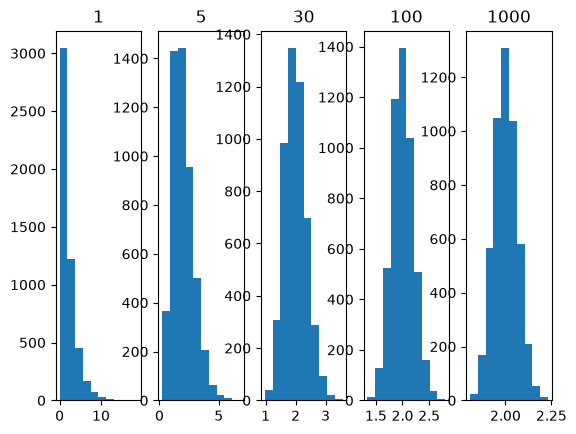

In [20]:
def simulate_clt(
  dist_sampler,
  sample_size: int,
  n_trials: int = 5000
) -> np.ndarray:
  """
  요구사항:
  - dist_sampler: size를 인자로 받아 그 크기만큼 표본을 뽑는 함수
    (예: lambda size: np.random.exponential(scale=2.0, size=size)).
  - n_trials번 반복해서, 매번 sample_size개를 뽑아 평균을 계산하고 기록.
  - n_trials개의 표본평균 배열을 반환한다.
  """
  means=[]
  #n_trials번 반복해서, 매번 sample_size개를 뽑아 평균을 계산하고 기록.
  for i in range(n_trials):
    samples = dist_sampler(sample_size)
    mean = np.mean(samples)
    means.append(mean)
  return np.array(means)

size = 10000
means = simulate_clt(lambda size: np.random.exponential(scale=2.0, size=size), 20)  
print(means)

def plot_clt_comparison(dist_sampler, sample_sizes: list[int]):
  """
  요구사항:
  - sample_sizes(예: [1, 5, 30, 100]) 각각에 대해 simulate_clt를 실행.
  - 각 결과의 히스토그램을 나란히(subplot) 그려, 표본 크기가 커질수록
    분포가 종 모양(정규분포)에 가까워지는 것을 시각적으로 비교.
  """
  means = []
  for i in sample_sizes:
    means.append(simulate_clt(dist_sampler, i))
  fig, axes = plt.subplots(1,len(sample_sizes))

  for i in range(len(means)):
    axes[i].hist(means[i])
    axes[i].set_title(f"{sample_sizes[i]}")
  plt.show()
  
plot_clt_comparison(lambda size: np.random.exponential(scale=2.0, size=size), [1,5,30,100,1000])